In [9]:
%load_ext autoreload
%autoreload 2

import panel as pn

import os

import torch
from ncpu.runner  import setup_trainer
from ncpu.config import TINY_AND_GATE_TRAINING_CONFIG
import mediapy as media

from matplotlib import pyplot as plt
from IPython.display import clear_output, display
from tqdm.auto import tqdm
from datetime import datetime
from ncpu.utils import print_tensor, sequence_batch_to_html_gifs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
# TrainRunnerUI(BIG_AND_GATE_TRAINING_CONFIG).render()

In [11]:
config = TINY_AND_GATE_TRAINING_CONFIG
trainer = setup_trainer(config)

Sanity check...
  forward: torch.Size([2, 16, 32, 32]) -> torch.Size([2, 11, 16, 32, 32])
  batch: 2
  dataloader: torch.Size([16, 32, 32]) -> torch.Size([16, 32, 32])
  first_state: torch.Size([16, 16, 32, 32])
  rollout: torch.Size([16, 11, 16, 32, 32])
  loss: 0.02123846858739853
Sanity check completed successfully


In [12]:
# state_dict = torch.load("notebooks/checkpoints/ncpu_127580_20251130_203719.pth")
# trainer.nca.load_state_dict(state_dict)

loss=0.006396:  32%|###2      | 32500/100000 [3:37:58<8:37:56,  2.17it/s]

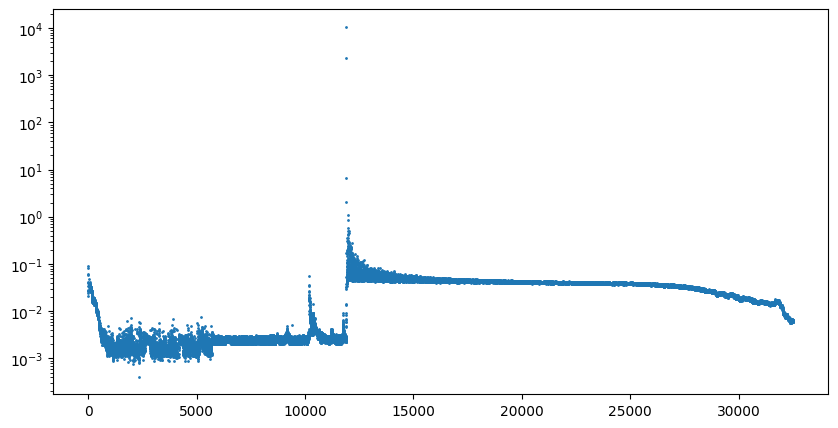

inp    : (16, 32, 32) torch.float32, min=0.00, max=1.74, mean=0.19, std=0.30
out    : (16, 32, 32) torch.float32, min=0.00, max=1.00, mean=0.11, std=0.32
nca_out: (16, 32, 32) torch.float32, min=-0.08, max=1.17, mean=0.17, std=0.34


,,,,,,,
,,,,,,,
,,,,,,,

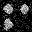
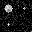
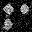
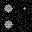
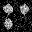
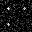
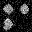
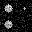
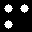
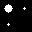
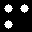
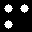
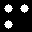
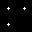
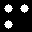
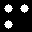
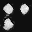
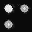
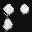
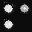
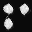
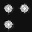
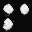
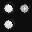

#0,#1,#2,#3,#4,#5,#6,#7

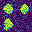
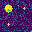
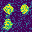
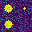
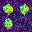
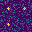
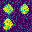
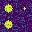

Show pool


,,,,,,,
,,,,,,,
,,,,,,,
,,,,,,,

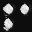
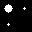
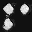
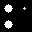
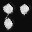
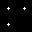
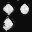
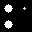
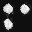
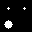
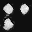
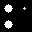
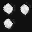
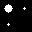
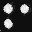
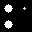
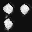
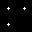
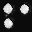
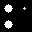
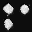
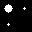
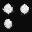
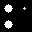
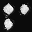
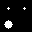
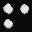
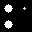
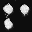
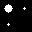
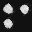
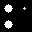

OutOfMemoryError: CUDA out of memory. Tried to allocate 80.00 MiB. GPU 0 has a total capacity of 5.67 GiB of which 74.06 MiB is free. Including non-PyTorch memory, this process has 5.57 GiB memory in use. Of the allocated memory 5.39 GiB is allocated by PyTorch, and 54.70 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [13]:
pbar = tqdm(range(10_000))
for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["loss"].item()
    pbar.set_description(f"loss={loss:.6f}")

    if i % 2500 == 0:
        clear_output(wait=False)
        display(pbar.container)
        fig, ax = plt.subplots(figsize=(10, 5))
        loss = [h["loss"].item() for h in trainer.history]
        ax.scatter(range(len(loss)), loss, s=1)
        ax.set_yscale("log")
        plt.close(fig)
        display(fig)

        print_tensor("inp    ", info["inp"])
        print_tensor("out    ", info["out"])
        print_tensor("nca_out", info["nca_out"])

        to_show = 8
        inp = info["inp"][:to_show]
        out = info["out"][:to_show]
        nca_out = info["nca_out"][:to_show]
        rollout = info["rollout"][:to_show]
        io = torch.cat([inp, out, nca_out], dim=0)

        media.show_images(
            io.detach().cpu(), columns=to_show, width=100, height=100
        )
        sequence_batch_to_html_gifs(rollout, columns=to_show, fps=10)

        print("Show pool")
        pool, pool_size = trainer.get_current_pool()
        pool = [t[0] for t in pool]
        media.show_images(
            pool, columns=to_show, width=100, height=100
        )


        it = len(trainer.history)
        path = f"./checkpoints/ncpu_{it}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth"
        torch.save(trainer.nca.state_dict(), path)